# RNN y sus aplicaciones en las series temporales

En este notebook se va a usar una RNN (recurrent neural network) para entrenar un modelo que sea capaz de predecir el comportamiento de una serie temporal.
Para ello, se usará un dataset de temperaturas.

## Descargar el dataset y almacenarlo

En primer lugar hay que importar tensorflow.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.15.0


El siguiente paso es importar las bibliotecas numpy y matplotlib. Además, se define el método **plot_series** que se utilizará para hacer las gráficas de las series temporales.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def plot_series(time, series, format="-", start=0, end=None):
    plt.plot(time[start:end], series[start:end], format)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)

A continuación se descarga el dataset de las temperaturas mínimas diarias.

In [ ]:
!wget --no-check-certificate \
    https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv \
    -O /tmp/daily-min-temperatures.csv

--2024-07-30 00:35:16--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 67921 (66K) [text/plain]
Saving to: ‘/tmp/daily-min-temperatures.csv’

/tmp/daily-min-temp 100%[===================>]  66.33K  --.-KB/s    in 0.01s   

2024-07-30 00:35:16 (4.87 MB/s) - ‘/tmp/daily-min-temperatures.csv’ saved [67921/67921]



En este paso, se utilizará la biblioteca csv de Python para guardar y poder leer el dataset de temperaturas mínimas diarias que ha sido descargado en el paso anterior. Además, se construye la variable **series** que será donde se guarde la serie temporal. Por último, siempre que se trate con una serie temporal, es una buena práctica hacer un gráfico para poder verla y tener una idea de cómo es.

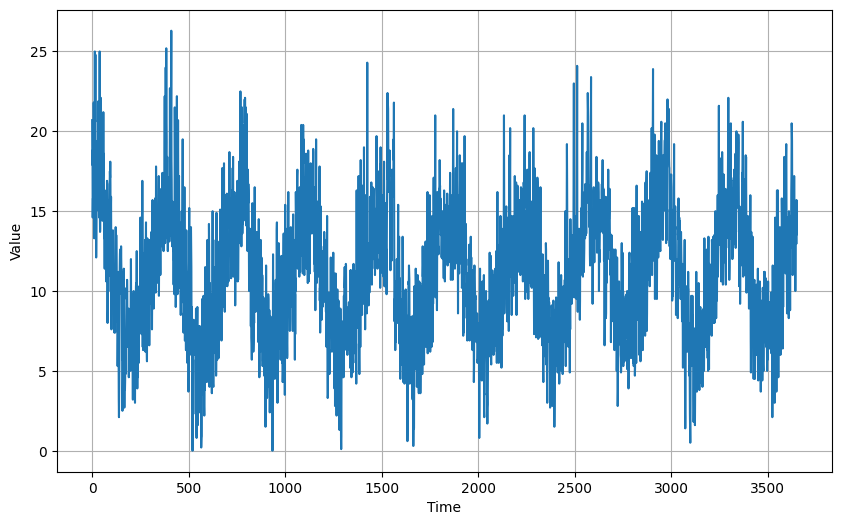

In [ ]:

import csv
time_step = []
temps = []

with open('/tmp/daily-min-temperatures.csv') as csvfile:
  reader = csv.reader(csvfile, delimiter=',')
  next(reader)
  step=0
  for row in reader:
    temps.append(float(row[1]))
    time_step.append(step)
    step = step + 1

series = np.array(temps)
time = np.array(time_step)
plt.figure(figsize=(10, 6))
plot_series(time, series)

## Creación de las variables necesarias para el diseño de la red neuronal

Una técnica muy común cuando se trata con series temporales es utilizar una ventana temporal que se vaya desplazando sobre la serie temporal para reducir su análisis a lo que ocurre en ese ventana de forma local, para a continuación realizar el modelado global.

Se crean las siguientes variables (dataset):

*   time_train
*   x_train
*   time_valid
*   x_valid





In [ ]:
## variables para la técnica de la ventana temporal
split_time = 2500
window_size = 30
batch_size = 32
shuffle_buffer_size = 1000

## Split del dataset en entrenamiento y validación

## Traint set
time_train = time[:split_time]
x_train = series[:split_time]

## Test set
time_valid = time[split_time:]
x_valid = series[split_time:]

Creación del método **windowed_dataset** para poder utilizarlo en el modelo. Los parámetros del método son:

*   series
*   window_size
*   batch_size
*   shuffle_buffer

El resto de elementos que se usan para construir la función ventana temporal para explorar el dataset, son métodos de Python para tratar con series temporales.




In [ ]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[1:]))
    return ds.batch(batch_size).prefetch(1)

### Función para predecir los siguientes valores de la serie temporal usando la técnica de la ventana temporal

A continuación, y usando como modelo el método **windowed_dataset** se procederá a adaptar el método **model_forecast** que se usará para predecir los siguientes valores de la serie temporal utilizando la técnica de la ventana temporal.


In [ ]:
def model_forecast(model, series, window_size):
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda w: w.batch(window_size))
  ds = ds.batch(32).prefetch(1)
  forecast = model.predict(ds)
  return forecast

A continuación, se limpia la sesión de keras, y se inicializan las variables necesarias para poder diseñar el modelo de series temporales a entrenar usando RNN.

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(51)
np.random.seed(51)
window_size = 64 # 60
batch_size = 256 # 100

## Diseño de la red neuronal

Crear la variable **train_set** dandole el valor que se reciba del método **windowed_dataset**, los parametros que debe recibir este método son: **x_train, window_size, batch_size, shuffle_buffer_size**

In [ ]:
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

Construir la red neuronal de aprendizaje profunda basada para modelar la serie temporal de las temperaturas minimas diarias. A continuación se dan las características de la red:

1.   Una capa de convolución en una dimensión que tenga 32 filtros, una tamaño del kernel de 5, un stride de 1, padding "causal", la función de activación debe ser relu y el input shape debe ser [None, 1]
2.   Una capa LSTM con 64 neuronas y retorno de secuencias
3.   Una capa LSTM con 64 neuronas y retorno de secuencias
4.   Una capa densa con 30 neuronas
5.   Una capa densa con 10 neuronas
6.   Una capa densa con 1 neuronas
7.   Por último, se añade la siguiente capa: tf.keras.layers.Lambda(lambda x: x * 400)




In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Lambda

model = Sequential()
model.add(Conv1D(filters=32, kernel_size=5, strides=1, padding="causal", activation="relu", input_shape=[None, 1]))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(64, return_sequences=True))
model.add(Dense(30, activation="relu"))
model.add(Dense(10, activation="relu"))
model.add(Dense(1, activation="relu"))
model.add(Lambda(lambda x: x * 400))

## Entrenamiento de la red neuronal

Se emplea un método callbacks para el learning rate que será guardado en la variable **lr_schedule**, este método deberá usar el método **LearningRateScheduler** de Python y será una función **lambda** que le de el valor a epoch de 1e-8 * 10 ** (epoch / 20)

In [ ]:
lr_schedule= tf.keras.callbacks.LearningRateScheduler(
  lambda epoch: 1e-8*10**(epoch/20)
)

Compilar la red neuronal con los siguientes parametros:

*   loss: método Huber de keras
*   El optimizador debe ser el SGD con learning rate 1e-8 y momentum 0.9
*   La métrica a visualizar es el error absoluto medio (medium absolute error en ingles)



In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-8, momentum=0.9),
              loss=tf.keras.losses.Huber(),
              metrics=["mae"])

Para terminar se entrena el modelo previamente diseñado y compilado en los pasos anteriores.

In [ ]:
history = model.fit(train_set, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
10/10 [==============================] - 8s 35ms/step - loss: 10.3119 - mae: 10.8109 - lr: 1.0000e-08
Epoch 2/100
10/10 [==============================] - 0s 31ms/step - loss: 10.3119 - mae: 10.8109 - lr: 1.1220e-08
Epoch 3/100
10/10 [==============================] - 0s 29ms/step - loss: 10.3118 - mae: 10.8108 - lr: 1.2589e-08
Epoch 4/100
10/10 [==============================] - 0s 31ms/step - loss: 10.3117 - mae: 10.8107 - lr: 1.4125e-08
Epoch 5/100
10/10 [==============================] - 1s 79ms/step - loss: 10.3116 - mae: 10.8106 - lr: 1.5849e-08
Epoch 6/100
10/10 [==============================] - 1s 70ms/step - loss: 10.3115 - mae: 10.8105 - lr: 1.7783e-08
Epoch 7/100
10/10 [==============================] - 1s 70ms/step - loss: 10.3113 - mae: 10.8103 - lr: 1.9953e-08
Epoch 8/100
10/10 [==============================] - 1s 80ms/step - loss: 10.3112 - mae: 10.8102 - lr: 2.2387e-08
Epoch 9/100
10/10 [==============================] - 2s 136ms/step - loss: 10.3110 - mae

## Actualización del learning rate según los resultados obtenidos del primer entrenamiento de la red neuronal

Después del entrenamiento de la red neuronal se ve que learning rate resultante es de 1e-5. Se visualizará gráficamente para entender el motivo por el que se ha usado ese valor. En la gráfica se puede ver cómo el learning rate con el que menos loss hay es 1e-5, y por ese motivo, se debe volver a entrenar la red neuronal con dicho learning rate.

(1e-08, 0.0001, 0.0, 12.0)

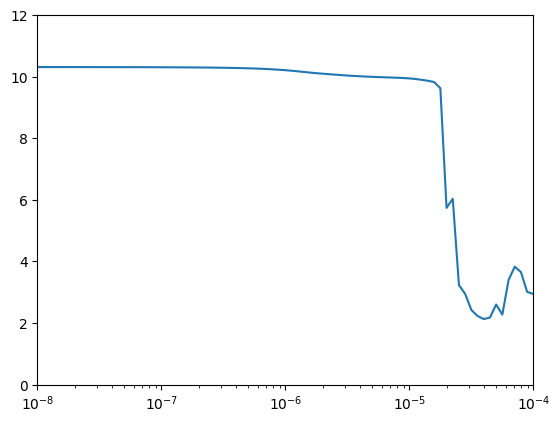

In [ ]:
plt.semilogx(history.history["lr"], history.history["loss"])
plt.axis([1e-8, 1e-4, 0, 12])

Se vuelve a inicializar la sesión de entrenamiento y la variable train_set:

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(51)
np.random.seed(51)
train_set = windowed_dataset(x_train, window_size=60, batch_size=100, shuffle_buffer=shuffle_buffer_size)

Se reutiliza la red neuronal diseñada previamente, pero esta vez se utilizan 60 filtros en la capa de convolución.

In [ ]:
model_ = Sequential()
model_.add(Conv1D(filters=60, kernel_size=5, strides=1, padding="causal", activation="relu", input_shape=[None, 1]))
model_.add(LSTM(64, return_sequences=True))
model_.add(LSTM(64, return_sequences=True))
model_.add(Dense(30))
model_.add(Dense(10))
model_.add(Dense(1))
model_.add(Lambda(lambda x: x * 400))


Se vuelve a compilar la red neuronal de manera análoga a la anterior, pero esta vez utilizar un learning rate obtenido de la función callback.

In [ ]:
model_.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9),
              loss=tf.keras.losses.Huber(),
              metrics=["mae"])

In [ ]:
history_ = model_.fit(train_set, epochs=150)

Epoch 1/150
25/25 [==============================] - 4s 35ms/step - loss: 38.0616 - mae: 38.5587
Epoch 2/150
25/25 [==============================] - 1s 35ms/step - loss: 35.0031 - mae: 35.5019
Epoch 3/150
25/25 [==============================] - 1s 28ms/step - loss: 18.2659 - mae: 18.7653
Epoch 4/150
25/25 [==============================] - 1s 19ms/step - loss: 14.1801 - mae: 14.6794
Epoch 5/150
25/25 [==============================] - 1s 17ms/step - loss: 11.8815 - mae: 12.3803
Epoch 6/150
25/25 [==============================] - 1s 18ms/step - loss: 10.5283 - mae: 11.0269
Epoch 7/150
25/25 [==============================] - 1s 17ms/step - loss: 9.5973 - mae: 10.0944
Epoch 8/150
25/25 [==============================] - 1s 19ms/step - loss: 8.7059 - mae: 9.2032
Epoch 9/150
25/25 [==============================] - 1s 19ms/step - loss: 7.7476 - mae: 8.2438
Epoch 10/150
25/25 [==============================] - 1s 17ms/step - loss: 7.5520 - mae: 8.0489
Epoch 11/150
25/25 [================

## Predicción de los siguientes valores de la serie temporal

Finalmente, se usa el método model_forecast que se ha diseñado utilizando el método de la ventana temporal para hacer el nuevo metodo rnn_forecast con el cual se calcularán los nuevos valores de la serie temporal. Posteriormente, se pinta una gráfica para ver esos resultados y comprobar de forma visual que son correctos. Además, se dan los resultados de esas predicciones en forma númerica.

In [ ]:
rnn_forecast = model_forecast(model_, series[..., np.newaxis], window_size)
rnn_forecast = rnn_forecast[split_time - window_size:-1, -1, 0]

113/113 [==============================] - 2s 11ms/step


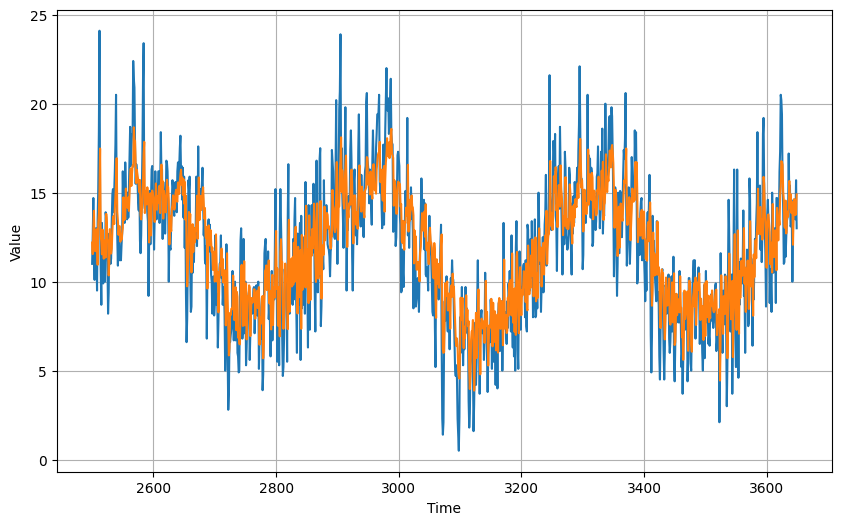

In [ ]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid)
plot_series(time_valid, rnn_forecast)

In [ ]:
tf.keras.metrics.mean_absolute_error(x_valid, rnn_forecast).numpy()

1.8007084

In [ ]:
print(rnn_forecast)

[12.196682 11.54869  12.98853  ... 13.943966 13.774671 14.89949 ]


## Gráficas de resultados.

Una vez obtenido el resultado de la actividad, se procede a revisr de forma gráfica el training y validation loss a lo largo de los epochs en este nuevo entrenamiento con el learning rate optimizado.

In [ ]:
import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Recuperar una lista de resultados de la lista de datos de entrenamiento y pruebas para cada epoch de entrenamiento
#-----------------------------------------------------------
loss=history_.history['loss']

epochs=range(len(loss)) # Get number of epochs

A continuación se realiza el plot de la pérdida frente a los epochs

<Figure size 640x480 with 0 Axes>

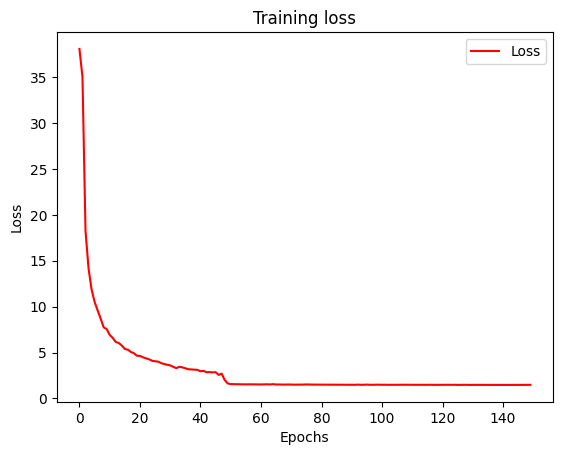

<Figure size 640x480 with 0 Axes>

In [ ]:
#------------------------------------------------
# Pérdida de entrenamiento y validación por epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r')
plt.title('Training loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss"])

plt.figure()

Utilizando las 2 nuevas variables zoomed_loss y zoomed_epochs y con base en el código anterior, hacer el plot del loss frente a los epochs entre los epoch 20 y 150 para ver como va oscilando y no es un proceso lineal como podria parecer según el anterior plot.

<Figure size 640x480 with 0 Axes>

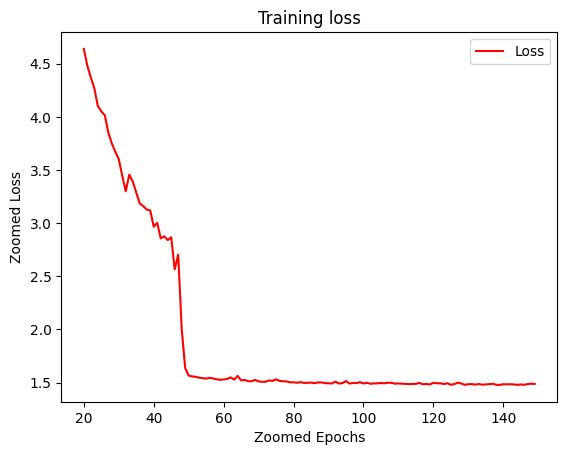

<Figure size 640x480 with 0 Axes>

In [ ]:
#------------------------------------------------
# Pérdida de entrenamiento y validación por epoch con zoom
#------------------------------------------------
zoomed_loss = loss[20:]
zoomed_epochs = range(20,150)


plt.plot(zoomed_epochs, zoomed_loss, 'r')
plt.title('Training loss')
plt.xlabel("Zoomed Epochs")
plt.ylabel("Zoomed Loss")
plt.legend(["Loss"])
plt.figure()